In [2]:
import torch
import torchvision.models as models #has pretrained models like ResNet, dataset loaders
import torchvision.transforms as transforms
from PIL import Image #handles Image files
import requests #fetches images from URL over HTTP
from io import BytesIO #wraps raw bytes into file-like object
import matplotlib.pyplot as plt
import numpy as np


Flow:
URL -> Requests -> BytesIO -> PIL.Image -> transforms -> tensor -> model

In [3]:
resnet = models.resnet50(pretrained = True)
print(resnet)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 158MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [4]:
#stripping head, freezing the weights
import torch.nn as nn

class ImageEmbedder(nn.Module):
  def __init__(self):
    super().__init__()

    resnet = models.resnet50(pretrained = True) #loading resnet

    for param in resnet.parameters():
      param.requires_grad = False #freezing to not retrained ImageNet

    #stripping the classification(FC) layer because resnet classifies 1000 ImageNet categories, we dont need the categories
    self.backbone = nn.Sequential(*list(resnet.children())[:-1])

    self.embedding_head = nn.Sequential(
        nn.Flatten(),
        nn.Linear(2048, 512), #2048 -> 512 (custom small head) to keep the embedding compact
        nn.ReLU()
    )

  def forward(self,x):
    features = self.backbone(x)
    embedding = self.embedding_head(features)
    return embedding

embedder = ImageEmbedder()
print("Model is ready")

Model is ready


In [7]:
#image transforming
transform = transforms.Compose([
    transforms.Resize((224,224)), #ResNet resolution
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406], #ImageNet mean per channel (RGB)
        std = [0.229, 0.224, 0.225] #ImageNet std per channel (RGB)
    )
])

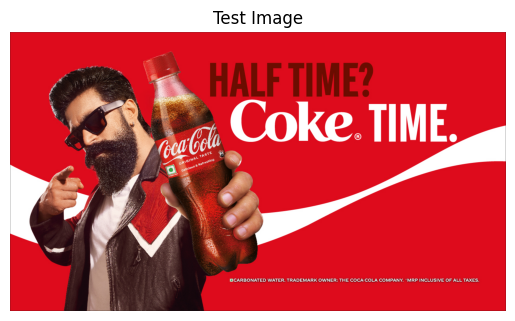

After transform: torch.Size([3, 224, 224])
With batch dim: torch.Size([1, 3, 224, 224])


In [11]:
#Testing with real image
url = "https://www.coca-cola.com/content/dam/onexp/in/en/homepage/half-time-coke-time_digital_1440x810px.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')

plt.imshow(img)
plt.title("Test Image")
plt.axis('off')
plt.show()

img_tensor = transform(img)
print(f"After transform: {img_tensor.shape}")

img_batch = img_tensor.unsqueeze(0) #for models
print(f"With batch dim: {img_batch.shape}")



In [12]:
#embedding
embedder.eval() #disables dropout

with torch.no_grad():
  embedding = embedder(img_batch)

print(f"Embedding Shape: {embedding.shape}")
print(f"Sample values: {embedding[0, :8]}")
print(f"All finite: {torch.isfinite(embedding).all()}") #sanity check

Embedding Shape: torch.Size([1, 512])
Sample values: tensor([0.0000, 0.0000, 0.4556, 0.0790, 0.0000, 0.2943, 0.1476, 0.3943])
All finite: True


In [13]:
#for multiple images
def load_and_embed(image_urls, embedder, transform):
  embeddings = []
  for url in image_urls:
    try:
      response = requests.get(url, timeout = 5)
      img = Image.open(BytesIO(response.content)).convert('RGB')
      tensor = transform(img).unsqueeze(0)

      with torch.no_grad():
        emb = embedder(tensor)
      embeddings.append(emb)

    except Exception as e:
      print(f"Failed on {url}: {e}") #doesnt let bad image crash the pipeline
      embeddings.append(torch.zeros(1,512))

  return torch.cat(embeddings, dim = 0)

#testing
test_urls = [
    "https://www.coca-cola.com/content/dam/onexp/in/en/homepage/half-time-coke-time_digital_1440x810px.jpg",
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQQxqVcbkm1XFv7xoYeZ5dJILg3wxZOR5jMXw&s",
    "https://i.pinimg.com/474x/b6/95/c3/b695c35d2feeba11ec91c563c9d353c4.jpg"
]

batch_embeddings = load_and_embed(test_urls, embedder, transform)
print(f"Batch embedding shape: {batch_embeddings.shape}")


Batch embedding shape: torch.Size([3, 512])


In [14]:
torch.save(embedder.state_dict(), 'image_embedder.pt')
print("Embedder saved")

Embedder saved
